# IFWI · SIREN coordinate network · Marmousi

**Implicit Full-Waveform Inversion** — instead of treating the velocity grid
`vp[nz, nx]` as the free parameter, we *parameterise* it with a small
coordinate-based MLP (SIREN; Sitzmann et al., 2020):

```
    vp(z, x)  =  vp_min + (vp_max - vp_min) * σ( MLP(z, x) )
```

FWI then optimises the **network weights**, not the velocity grid. The SIREN's
finite spectral bandwidth (controlled by `w0`) acts as an *implicit smoothness
prior* — the recovered model is naturally band-limited, which suppresses the
high-wavenumber speckle that plagues vanilla grid FWI when sources are sparse
or data is noisy.

Reference: Sun, J., Innanen, K., Zhang, T., & Trad, D. (2023). *Implicit
Seismic Full Waveform Inversion With Deep Neural Representation.* Journal of
Geophysical Research: Solid Earth,
[doi:10.1029/2022JB025964](https://doi.org/10.1029/2022JB025964).

This notebook is a drop-in alternative to `01_fwi_acoustic_marmousi.ipynb` —
the data path (equation, solver, geometry, wavelet, shot batching) is
identical, only the parameterisation changes.

1. imports + parameters
2. truth + initial smooth model (downsampled Marmousi)
3. SIREN network + coordinate grid
4. solver + survey geometry
5. SIREN warm-start + IFWI loop, looped over three parametrisations
6. results (truth / initial / IFWI side-by-side)

## 1. Imports and parameters

In [1]:
import time
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sweep.equations import Acoustic
from sweep.propagator.torch import PropTorch
from sweep.signal import ricker
from sweep.datasets import load_marmousi, MARMOUSI_DH

# --- physics / acquisition (identical to nb01) ---
dh    = MARMOUSI_DH * 2   # 25 m via [::2, ::2] downsample
dt    = 0.002
nt    = 2000              # 4.0 s
freq  = 5.0
delay = 0.20
nshots, nrec, batch_shots = 20, 200, 8
src_z, rec_z = 2, 4

# --- IFWI hyperparameters ---
siren_hidden  = 128
siren_layers  = 4
siren_w0      = 30.0
vp_min, vp_max = 1500.0, 4500.0
lr_fwi        = 1e-4      # Adam on SIREN weights (not vp directly)
n_iter        = 500
warm_start_iters = 500    # pre-fit SIREN to the smooth initial model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(0)
print('device:', device)

device: cuda


## 2. Truth and initial-model setup

Same downsampled Marmousi pair as nb01.

In [2]:
vp_true_np = load_marmousi('true')[::2, ::2].copy()
vp_init_np = load_marmousi('smooth')[::2, ::2].copy()
shape      = vp_true_np.shape
nz, nx     = shape
print('shape:', shape,
      f'  physical extent: {nz*dh/1000:.1f} km depth × {nx*dh/1000:.1f} km offset')
print(f'vp range  true=[{vp_true_np.min():.0f}, {vp_true_np.max():.0f}]'
      f'  init=[{vp_init_np.min():.0f}, {vp_init_np.max():.0f}]'
      f'  siren bounds=[{vp_min:.0f}, {vp_max:.0f}]')

# Pre-compute torch tensor + mean/std of the smooth init — needed by the
# 'affine' and 'perturb' parametrisations defined in cell 7.
vp_init_t    = torch.tensor(vp_init_np, device=device, dtype=torch.float32)
vp_init_mean = float(vp_init_np.mean())
vp_init_std  = float(vp_init_np.std())
print(f'vp_init  mean = {vp_init_mean:.1f}  std = {vp_init_std:.1f}')

shape: (141, 681)   physical extent: 3.5 km depth × 17.0 km offset
vp range  true=[1028, 4700]  init=[1501, 4288]  siren bounds=[1500, 4500]
vp_init  mean = 2671.8  std = 877.1


## 3. SIREN network and the `vp_from_siren` reparameterisation

Canonical Sitzmann 2020 sine-activated MLP. First-layer weights are sampled
from `U(-1/in_f, 1/in_f)`; hidden layers from `U(-sqrt(6/in_f)/w0, +sqrt(6/in_f)/w0)`
so the pre-activation distribution is roughly standard-normal regardless of
depth.

The coordinate grid `coords` is **constant across iterations** — only the SIREN
weights change. The output is squashed by `sigmoid` and linearly mapped to
`[vp_min, vp_max]`, so the returned `vp` is a torch tensor that lives in the
autograd graph of the SIREN parameters — SWEEP's adjoint will route gradients
from data misfit back through the network without any extra plumbing.

In [3]:
class SineLayer(nn.Module):
    """Sitzmann 2020 canonical sine-activated linear layer."""
    def __init__(self, in_f, out_f, w0=30.0, is_first=False):
        super().__init__()
        self.w0 = w0
        self.linear = nn.Linear(in_f, out_f)
        with torch.no_grad():
            if is_first:
                self.linear.weight.uniform_(-1.0 / in_f, 1.0 / in_f)
            else:
                b = (6.0 / in_f) ** 0.5 / w0
                self.linear.weight.uniform_(-b, b)

    def forward(self, x):
        return torch.sin(self.w0 * self.linear(x))


class SIREN(nn.Module):
    """Strict Sitzmann 2020 SIREN — first/hidden layers always use the paper
    init. The final linear's init is controlled by ``final_layer_init``:

      * 'paper'   — `U(±√(6/in)/w0)` (paper reference implementation)
        small output magnitude → good with the 'affine' / 'perturb'
        parametrisations (network starts ≈ 0 → vp starts ≈ vp_init).
      * 'default' — PyTorch default `U(±1/√in)`, ~12× larger magnitude
        sigmoid squashes large pre-activations into [0, 1] gracefully, so this
        init gives noticeably faster IFWI convergence for the 'sigmoid' mode.
    """
    def __init__(self, hidden=128, n_layers=4, w0=30.0, final_layer_init='paper'):
        super().__init__()
        layers = [SineLayer(2, hidden, w0=w0, is_first=True)]
        for _ in range(n_layers - 1):
            layers.append(SineLayer(hidden, hidden, w0=w0))
        final = nn.Linear(hidden, 1)
        if final_layer_init == 'paper':
            with torch.no_grad():
                b = (6.0 / hidden) ** 0.5 / w0
                final.weight.uniform_(-b, b)
        elif final_layer_init == 'default':
            pass  # keep PyTorch's nn.Linear default initialiser
        else:
            raise ValueError(f'unknown final_layer_init: {final_layer_init!r}')
        layers.append(final)
        self.net = nn.Sequential(*layers)

    def forward(self, coords):
        return self.net(coords)


# Normalised (z, x) coordinate grid in [-1, 1] × [-1, 1] — constant every iter.
zz, xx = torch.meshgrid(
    torch.linspace(-1.0, 1.0, nz, device=device),
    torch.linspace(-1.0, 1.0, nx, device=device),
    indexing='ij',
)
coords = torch.stack([zz, xx], dim=-1).reshape(-1, 2)  # (nz*nx, 2)


def vp_from_siren(net, mode='sigmoid'):
    """vp(z, x) from a SIREN net + a coordinate grid. Three parametrisations:

      * 'sigmoid' — bounded:   vp = vp_min + (vp_max − vp_min) · σ(net(coords))
      * 'affine'  — Gaussian:  vp = mean(vp_init) + std(vp_init) · net(coords)
      * 'perturb' — additive:  vp = vp_init       + std(vp_init) · net(coords)

    'sigmoid' is the safe default — output is clipped into a physical range
    regardless of network output magnitude. 'affine' drops the squash for a
    Gaussian-style prior centred on the init mean. 'perturb' treats the SIREN
    as a *perturbation* on top of the smooth initial model, which lets the
    inversion focus on recovering geological structure rather than the bulk
    velocity field.
    """
    out = net(coords).reshape(nz, nx)
    if mode == 'sigmoid':
        return vp_min + (vp_max - vp_min) * torch.sigmoid(out)
    if mode == 'affine':
        return vp_init_mean + vp_init_std * out
    if mode == 'perturb':
        return vp_init_t + vp_init_std * out
    raise ValueError(f'unknown vp_from_siren mode: {mode!r}')


# Recommended SIREN final-layer init per parametrisation — pick the one that
# matches the mode's output scale (sigmoid needs large pre-activations to
# break out of σ ≈ 0.5; affine/perturb need small ones so the unbounded
# output stays near zero at init).
FINAL_INIT_BY_MODE = {'sigmoid': 'default', 'affine': 'paper', 'perturb': 'paper'}


# Sanity check: random-init network should produce a vp grid in the right
# ballpark for each mode (using its recommended final-layer init).
for mode in FINAL_INIT_BY_MODE:
    net_demo = SIREN(hidden=siren_hidden, n_layers=siren_layers, w0=siren_w0,
                     final_layer_init=FINAL_INIT_BY_MODE[mode]).to(device)
    with torch.no_grad():
        vp0 = vp_from_siren(net_demo, mode=mode)
    print(f'  mode={mode:<8s}  final_init={FINAL_INIT_BY_MODE[mode]:<8s}'
          f'  vp(random)  mean={vp0.mean().item():.0f}'
          f'  min={vp0.min().item():.0f}  max={vp0.max().item():.0f}')
    del net_demo

  mode=sigmoid   final_init=default   vp(random)  mean=2539  min=2077  max=3110
  mode=affine    final_init=paper     vp(random)  mean=2666  min=2608  max=2716
  mode=perturb   final_init=paper     vp(random)  mean=2687  min=1492  max=4319


## 4. Solver + survey geometry

Identical to nb01: 20 surface shots, 200-receiver horizontal streamer,
`Acoustic` + `PropTorch(impl='c')` (compiled CUDA backend; eager fallback if
the binding is missing).

In [4]:
t = np.arange(nt, dtype=np.float32) * dt
wavelet = ricker(t - delay, f=freq)

src_x = np.linspace(nx * 0.1, nx * 0.9, nshots).astype(np.int64)
rec_x = np.linspace(0, nx - 1, nrec).astype(np.int64)
sources   = np.stack([src_x, np.full(nshots, src_z, dtype=np.int64)], axis=1)
receivers = np.stack([rec_x, np.full(nrec,   rec_z, dtype=np.int64)], axis=1)
receivers = np.repeat(receivers[None, ...], nshots, axis=0)

equation = Acoustic(device=device)
solver   = PropTorch(equation, shape=shape, dh=dh, dt=dt, impl='c')
if solver.impl == 'eager':
    batch_shots = min(batch_shots, 2)
print('impl:', solver.impl, ' batch_shots:', batch_shots)

# Forward-model the observed data with the true vp (no autograd needed).
vp_true = torch.tensor(vp_true_np, device=device)
with torch.no_grad():
    observed = solver(wavelet, sources, receivers, models=[vp_true]).detach()
print('observed shape:', tuple(observed.shape))

impl: c  batch_shots: 8
observed shape: (20, 2000, 200, 1)


## 5. Inversion · loop over three parametrisations

For each `mode` in `('sigmoid', 'affine', 'perturb')`:

1. Build a fresh SIREN with paper-correct init.
2. Warm-start it against `vp_init` via the chosen parametrisation
   (network learns to reproduce the smooth initial model).
3. Run the same stochastic mini-batch IFWI loop on the same observed shots
   with the same Adam hyperparameters.
4. Cache the recovered vp, the loss trajectory, and wall-clock.

This keeps the comparison apples-to-apples — the only thing that changes
between runs is how the SIREN output is mapped to vp.

In [5]:
PARAMETRIZATIONS = ['sigmoid', 'affine', 'perturb']
warm_start_lr = 1e-3
results = {}

print(f'Running {len(PARAMETRIZATIONS)} parametrisations × '
      f'({warm_start_iters} warm-start + {n_iter} IFWI iters) each')
print('=' * 78)

for seed_offset, mode in enumerate(PARAMETRIZATIONS):
    print(f'\n=== mode = {mode!r}  (final_layer_init = {FINAL_INIT_BY_MODE[mode]!r}) '
          + '=' * max(0, 74 - len(repr(mode)) - len(repr(FINAL_INIT_BY_MODE[mode])) - 26))
    torch.manual_seed(seed_offset)
    net = SIREN(hidden=siren_hidden, n_layers=siren_layers, w0=siren_w0,
                final_layer_init=FINAL_INIT_BY_MODE[mode]).to(device)

    # ---- warm-start: fit SIREN to vp_init via the chosen parametrisation ----
    wopt = torch.optim.Adam(net.parameters(), lr=warm_start_lr)
    for step in range(warm_start_iters):
        wopt.zero_grad()
        loss = (vp_from_siren(net, mode=mode) - vp_init_t).pow(2).mean()
        loss.backward()
        wopt.step()
        if step % 100 == 0 or step == warm_start_iters - 1:
            print(f'  warm-start  step {step:4d}  L2(vp_pred, vp_init) = {loss.item():.3e}')
    with torch.no_grad():
        warm_rel = ((vp_from_siren(net, mode=mode) - vp_init_t).norm()
                    / vp_init_t.norm()).item()
    print(f'  warm-started SIREN  rel-L2 vs vp_init = {warm_rel:.3e}')

    # ---- reset Adam: drop the warm-start optimiser (and its m_t / v_t moment
    #      buffers) and instantiate a fresh one for IFWI so the inversion
    #      doesn't inherit any of the warm-start's accumulated gradient stats.
    del wopt
    torch.cuda.empty_cache() if device.type == 'cuda' else None
    rng = np.random.default_rng(0)
    fwi_opt = torch.optim.Adam(net.parameters(), lr=lr_fwi, eps=1e-16)
    losses = []
    t_start = time.time()
    for it in range(n_iter):
        idx = rng.choice(nshots, size=batch_shots, replace=False)
        fwi_opt.zero_grad()
        vp = vp_from_siren(net, mode=mode)
        predicted = solver(wavelet, sources[idx], receivers[idx], models=[vp])
        loss = (predicted - observed[idx]).pow(2).mean()
        loss.backward()
        fwi_opt.step()
        if device.type == 'cuda':
            torch.cuda.synchronize()
        losses.append(float(loss.detach().cpu()))
        if it < 3 or (it + 1) % 100 == 0 or it == n_iter - 1:
            print(f'  iter {it:03d}  loss {losses[-1]:.4e}  total={time.time()-t_start:.1f}s')

    with torch.no_grad():
        vp_final = vp_from_siren(net, mode=mode).cpu().numpy()
    results[mode] = {
        'vp_final': vp_final,
        'losses': losses,
        'warm_rel': warm_rel,
        'wall_clock_s': time.time() - t_start,
    }

print('\n' + '=' * 78)
print('DONE — final misfits:')
for mode in PARAMETRIZATIONS:
    r = results[mode]
    print(f"  {mode:<8s}  loss {r['losses'][-1]:.3e}"
          f"  ({r['losses'][0] / r['losses'][-1]:.1f}× drop)"
          f"  wall {r['wall_clock_s']:.1f} s")

Running 3 parametrisations × (500 warm-start + 500 IFWI iters) each

=== mode = 'sigmoid'  (final_layer_init = 'default') ==============================


  warm-start  step    0  L2(vp_pred, vp_init) = 8.266e+05


  warm-start  step  100  L2(vp_pred, vp_init) = 4.840e+02


  warm-start  step  200  L2(vp_pred, vp_init) = 1.817e+02


  warm-start  step  300  L2(vp_pred, vp_init) = 1.030e+02


...

  iter 099  loss 3.5593e-03  total=25.9s


  iter 199  loss 2.2079e-03  total=51.8s


  iter 299  loss 1.5484e-03  total=77.5s


  iter 399  loss 1.2712e-03  total=103.4s


  iter 499  loss 8.5060e-04  total=129.2s

DONE — final misfits:
  sigmoid   loss 1.371e-03  (75.9× drop)  wall 119.2 s
  affine    loss 5.462e-02  (1.0× drop)  wall 129.4 s
  perturb   loss 8.506e-04  (64.0× drop)  wall 129.2 s


## 6. Comparison

Three parametrisations, three SIRENs, identical Marmousi truth + same observed
shots + same Adam hyperparameters. The only thing that changes is how the
SIREN output maps to the velocity model:

| mode      | formula                                          | bounded? | baseline |
|-----------|--------------------------------------------------|----------|----------|
| `sigmoid` | `vp = vp_min + (vp_max−vp_min)·σ(net(coords))`   | hard `[vp_min, vp_max]` | scalar `(vp_min+vp_max)/2` |
| `affine`  | `vp = mean(vp_init) + std(vp_init)·net(coords)`  | unbounded | scalar `mean(vp_init)` |
| `perturb` | `vp = vp_init + std(vp_init)·net(coords)`        | unbounded | full `vp_init` (spatially varying) |

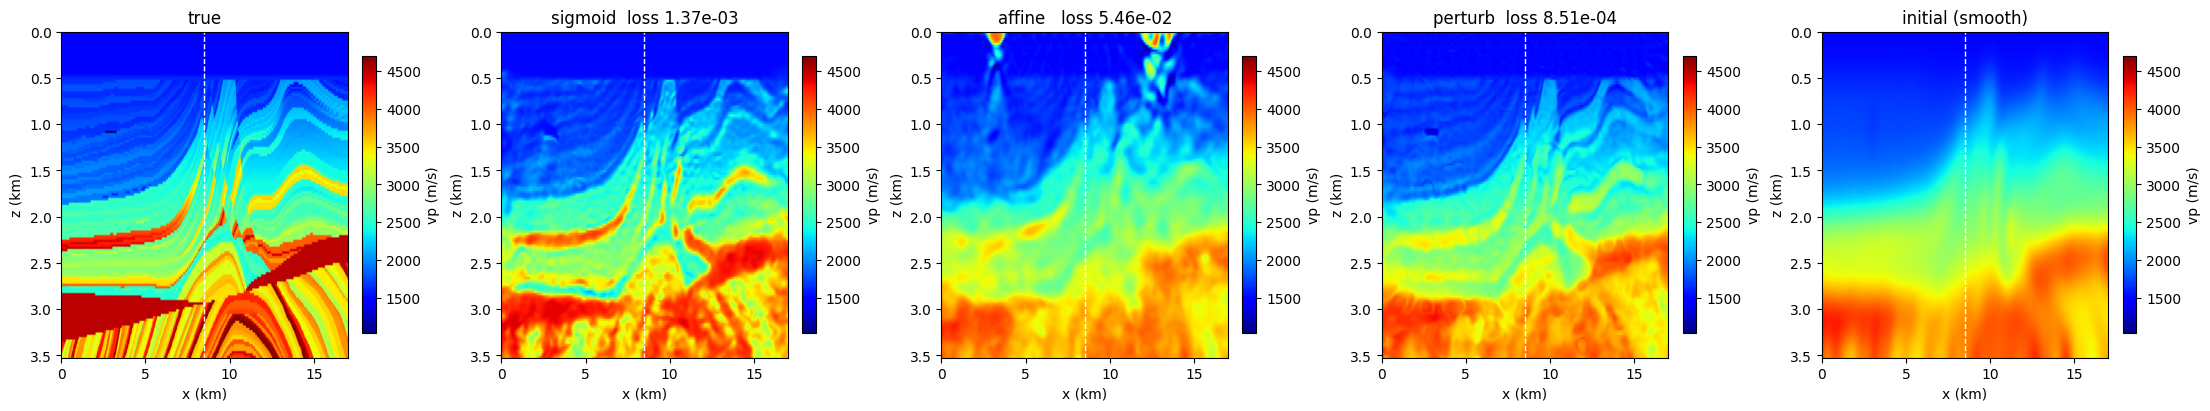

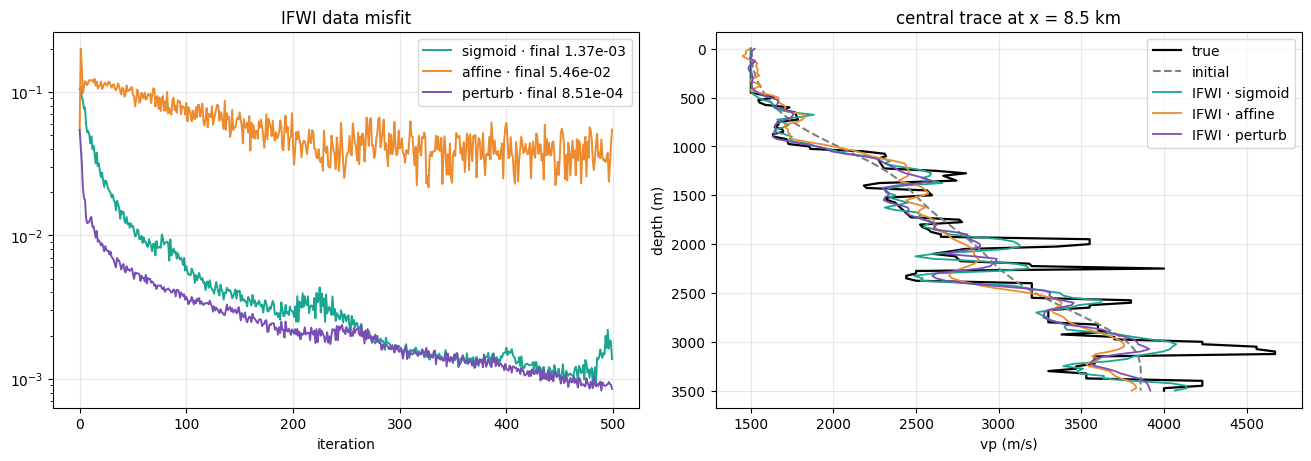

In [6]:
vmin_m = float(min(
    vp_true_np.min(), vp_init_np.min(),
    *(r['vp_final'].min() for r in results.values()),
))
vmax_m = float(max(
    vp_true_np.max(), vp_init_np.max(),
    *(r['vp_final'].max() for r in results.values()),
))
x_trace = nx // 2
z_axis  = np.arange(nz) * dh

# 1×5 imshow grid: true | sigmoid | affine | perturb | init
fig, axes = plt.subplots(1, 5, figsize=(22, 4), constrained_layout=True)
panels = [
    (vp_true_np, 'true'),
    (results['sigmoid']['vp_final'], f"sigmoid  loss {results['sigmoid']['losses'][-1]:.2e}"),
    (results['affine']['vp_final'],  f"affine   loss {results['affine']['losses'][-1]:.2e}"),
    (results['perturb']['vp_final'], f"perturb  loss {results['perturb']['losses'][-1]:.2e}"),
    (vp_init_np, 'initial (smooth)'),
]
for ax, (m, title) in zip(axes, panels):
    im = ax.imshow(m, cmap='jet', vmin=vmin_m, vmax=vmax_m, aspect='auto',
                   extent=[0, nx*dh/1000, nz*dh/1000, 0])
    ax.axvline(x_trace * dh / 1000, color='w', linewidth=1.0, linestyle='--')
    ax.set_title(title); ax.set_xlabel('x (km)'); ax.set_ylabel('z (km)')
    fig.colorbar(im, ax=ax, shrink=0.85, label='vp (m/s)')
plt.show()

# Loss curves + central trace
colors = {'sigmoid': '#1AA690', 'affine': '#ED8B2E', 'perturb': '#7A4FB5'}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)

for mode in PARAMETRIZATIONS:
    r = results[mode]
    axes[0].plot(r['losses'],
                 label=f'{mode} · final {r["losses"][-1]:.2e}',
                 color=colors[mode], linewidth=1.4)
axes[0].set_title('IFWI data misfit')
axes[0].set_xlabel('iteration'); axes[0].set_yscale('log')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(vp_true_np[:, x_trace], z_axis, label='true',
             color='k', linewidth=1.6)
axes[1].plot(vp_init_np[:, x_trace], z_axis, label='initial',
             color='gray', linestyle='--')
for mode in PARAMETRIZATIONS:
    axes[1].plot(results[mode]['vp_final'][:, x_trace], z_axis,
                 label=f'IFWI · {mode}', color=colors[mode], linewidth=1.3)
axes[1].invert_yaxis()
axes[1].set_xlabel('vp (m/s)'); axes[1].set_ylabel('depth (m)')
axes[1].set_title(f'central trace at x = {x_trace * dh / 1000:.1f} km')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.show()

---

<p><strong>Download this notebook</strong> &mdash; <a href="13_ifwi_siren.ipynb" download><code>13_ifwi_siren.ipynb</code></a> &middot; or <a href="https://github.com/DeepWave-KAUST/sweep/blob/dev/examples/notebooks/13_ifwi_siren.ipynb">view on GitHub</a></p>